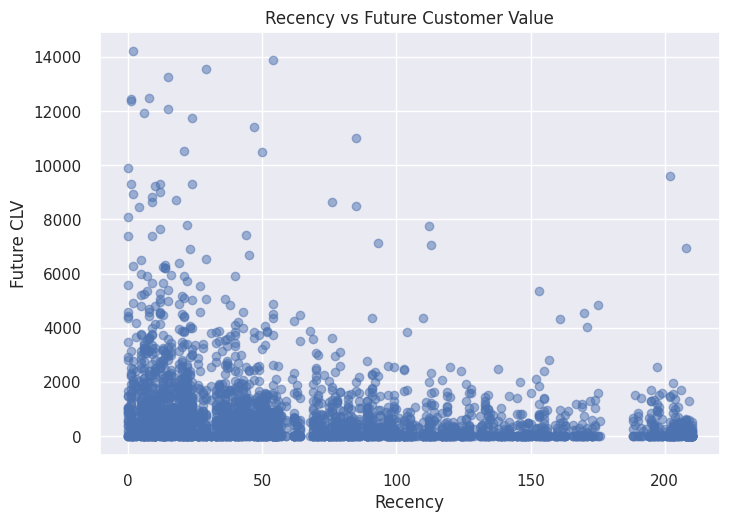

'Online Retail.xlsx'	     sample_data
 rf_feature_importance.png   xgb_feature_importance.png
            Recency  Frequency  Monetary  AvgOrderValue  Tenure  \
CustomerID                                                        
12346.0         162          1  77183.60   77183.600000     162   
12347.0          20          4   2205.95     551.487500     204   
12348.0          85          3   1487.24     495.746667     194   
12350.0         147          1    334.40     334.400000     147   
12352.0          99          5   1561.81     312.362000     133   

            TotalQuantity    AvgGap     StdGap  Momentum  Future_CLV  
CustomerID                                                            
12346.0             74215  0.000000   0.000000       0.0         NaN  
12347.0              1313  1.801980  10.460420       0.0     2104.05  
12348.0              2124  4.037037  15.166972      -1.0      310.00  
12350.0               197  0.000000   0.000000       0.0         NaN  
12352.0   

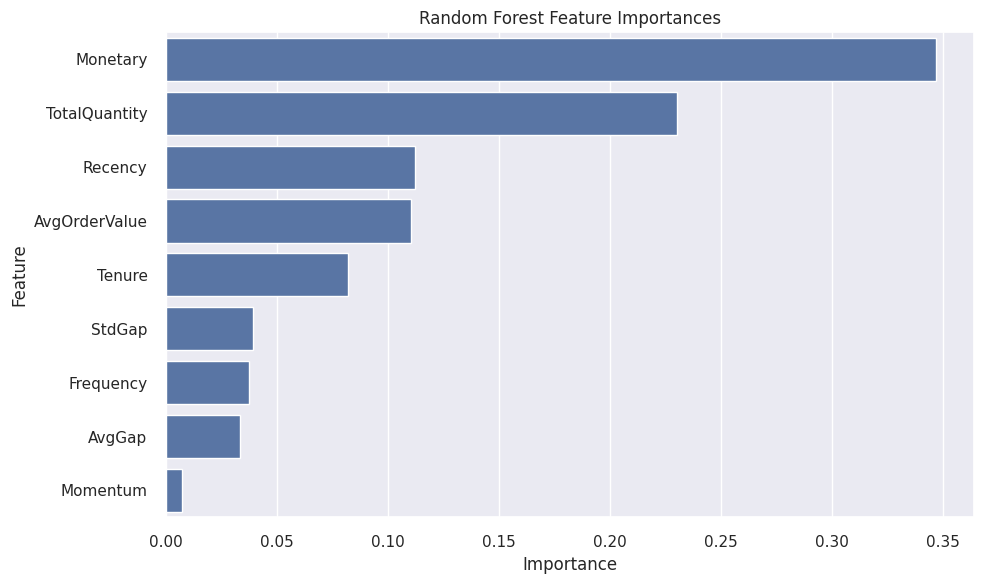

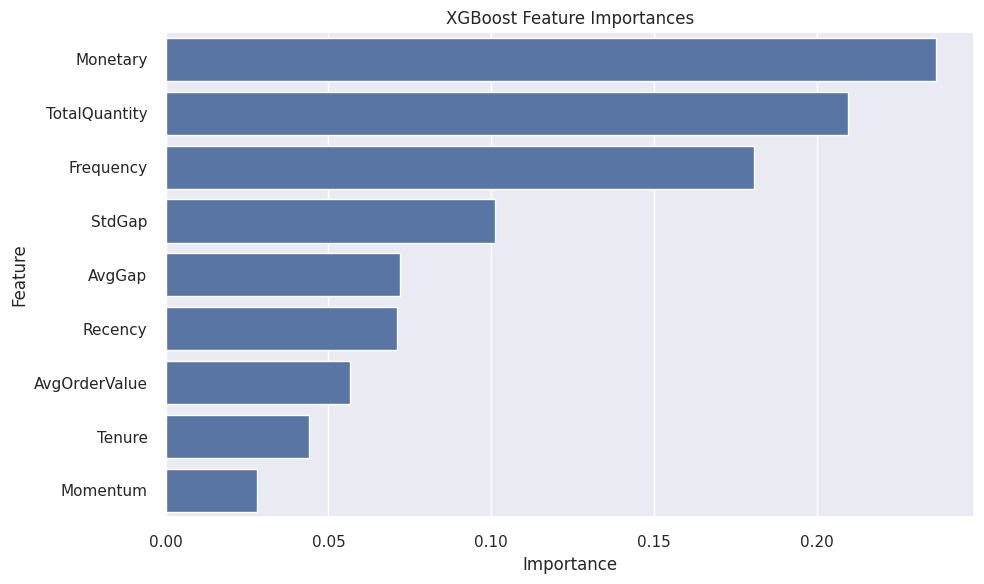

Random Forest and XGBoost Feature Importances extracted and visualized.
Training models and making predictions for residual analysis...
Models trained, predictions made, and residuals calculated.

First 5 Linear Regression Residuals: [131.08921123 156.13454541 277.32036757 -52.9821726  646.91163483]
First 5 Random Forest Residuals: [255.56355087 136.35139643 260.78039907 -13.07170966 634.99447679]
First 5 Gradient Boosting Residuals: [225.90300703 135.0885036  275.4678283   -8.1162461  638.36682642]
First 5 XGBoost Residuals: [432.72718506 142.73315292 217.06915985 -14.5305357  651.49249023]


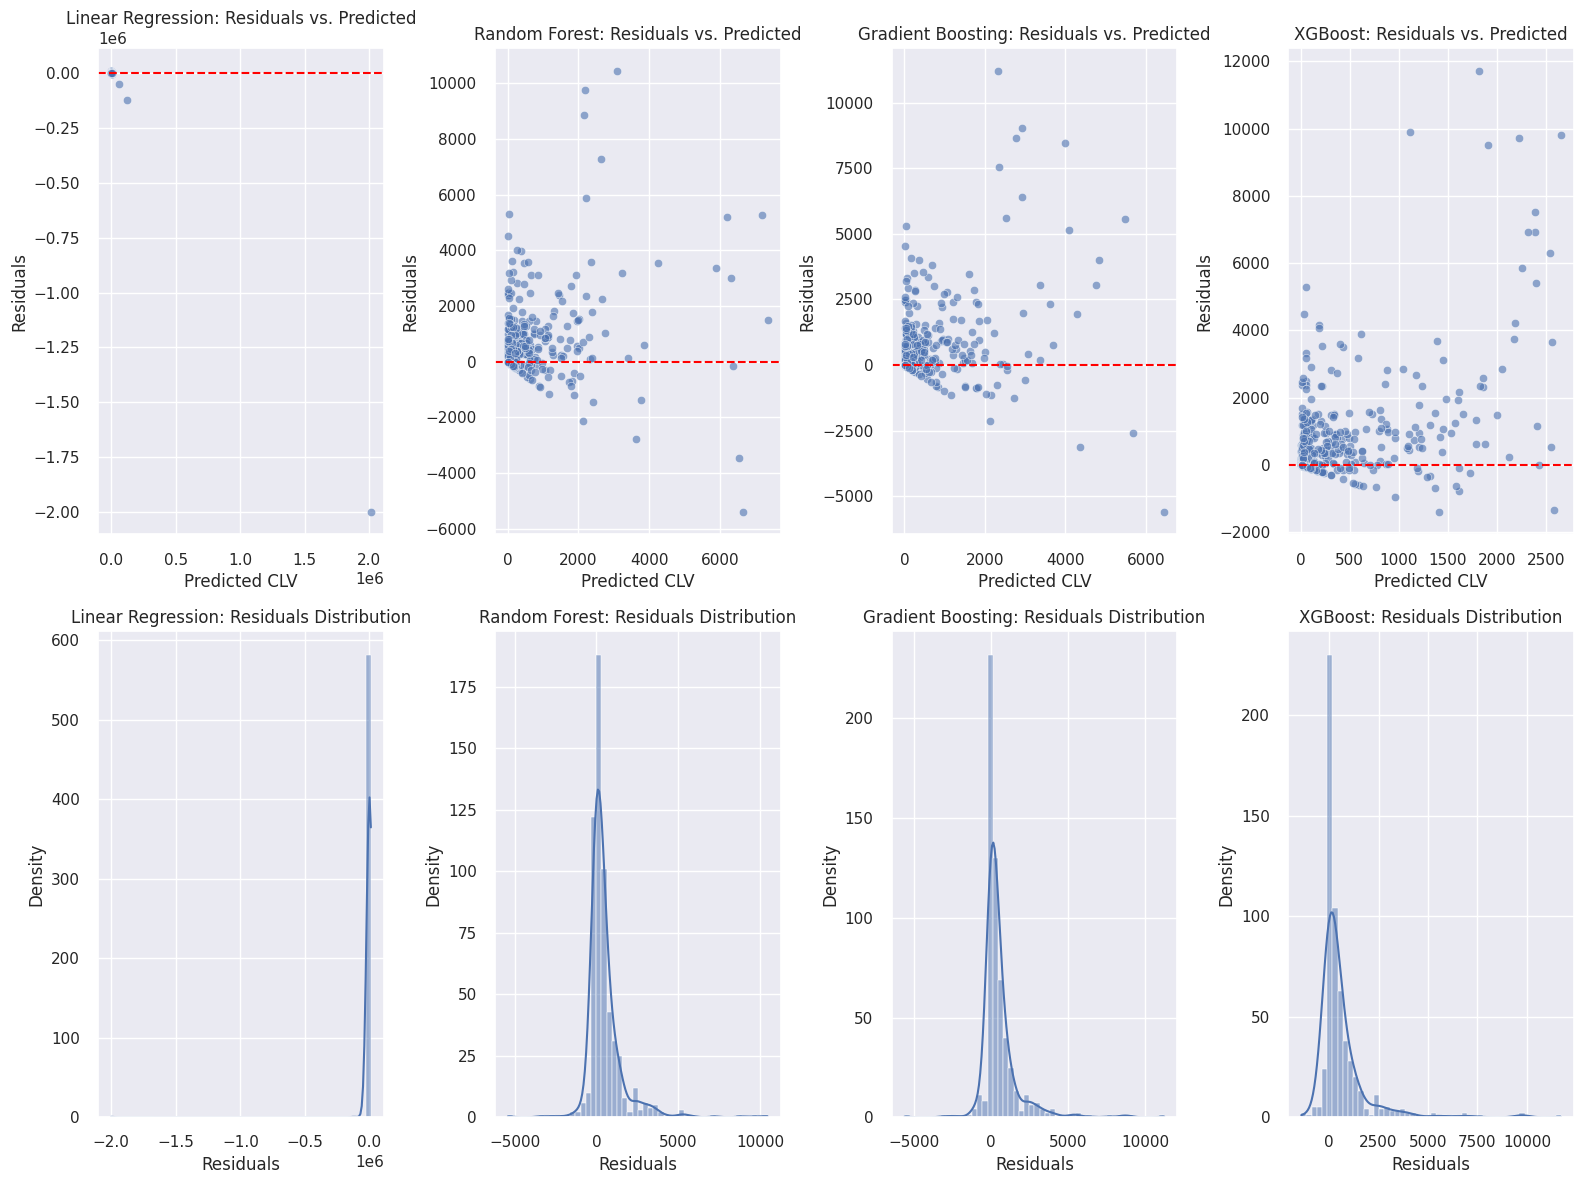

Residual plots generated and displayed for all models.
Table 1: Descriptive Statistics for Engineered Features and Future_CLV
|               | count   | mean      | std     | min   | 25%     | 50%      | 75%     | max     |
|:--------------|:--------|:----------|:--------|:------|:--------|:---------|:--------|:--------|
| Recency       | 2924    | 71.4904   | 59.7295 | 0     | 21      | 52       | 111     | 210     |
| Frequency     | 2924    | 2.73256   | 3.24192 | 1     | 1       | 2        | 3       | 56      |
| Monetary      | 2924    | 1039.22   | 2339.73 | 3.75  | 249.457 | 490.285  | 1104.48 | 77183.6 |
| AvgOrderValue | 2924    | 391.758   | 1505.1  | 3.75  | 170.355 | 285.915  | 409.841 | 77183.6 |
| Tenure        | 2924    | 129.719   | 62.5583 | 0     | 82      | 134      | 196     | 210     |
| TotalQuantity | 2924    | 600.965   | 1768.33 | 1     | 120     | 270      | 627.25  | 74215   |
| AvgGap        | 2924    | 1.8225    | 6.54649 | 0     | 0       | 0.272727 | 1.7

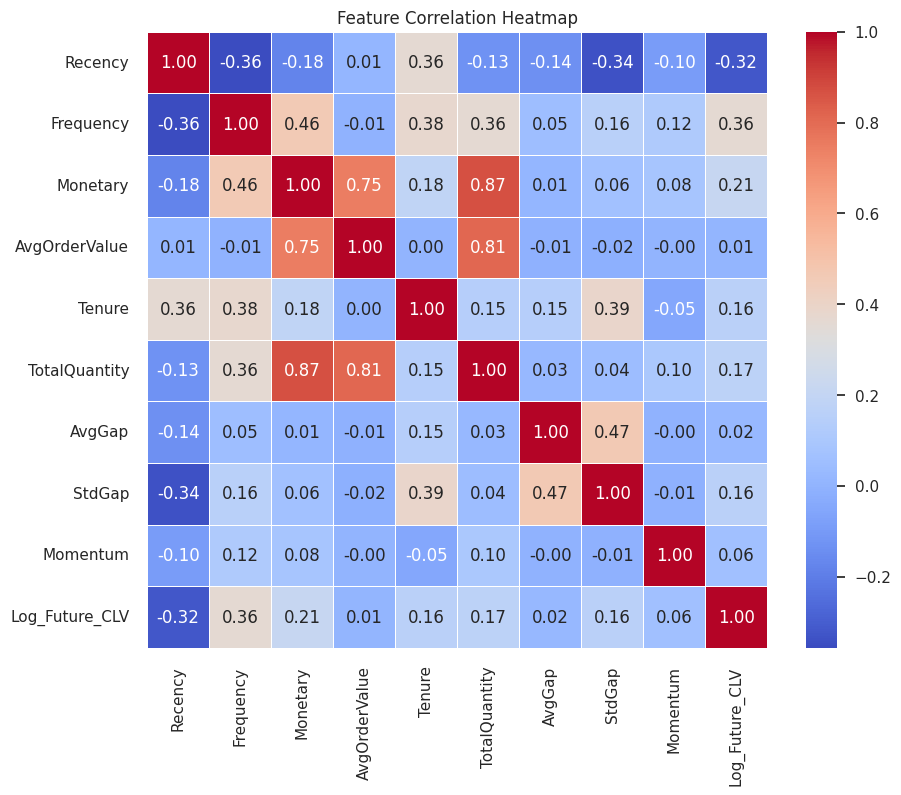

Feature correlation matrix and heatmap generated and displayed.
Table 3: Model Performance (on back-transformed CLV values)
| Model             | Mean MAE    | Mean RMSE   | Mean R²      |
|:------------------|:------------|:------------|:-------------|
| Random Forest     | 615.126     | 1179.62     | 0.349        |
| Gradient Boosting | 620.296     | 1209.92     | 0.312        |
| XGBoost           | 644.961     | 1314.68     | 0.19         |
| Linear Regression | 1.52447e+08 | 3.00668e+09 | -1.91572e+13 |
Table 4: Cross-Validation Results (RMSE)
| Model             | Mean RMSE   | Std Dev RMSE   | 95% CI Lower   | 95% CI Upper   |
|:------------------|:------------|:---------------|:---------------|:---------------|
| Random Forest     | 1179.62     | 148.471        | 1049.47        | 1309.76        |
| Gradient Boosting | 1209.92     | 133.128        | 1093.23        | 1326.61        |
| XGBoost           | 1314.68     | 139.282        | 1192.59        | 1436.76        |
| Linear R

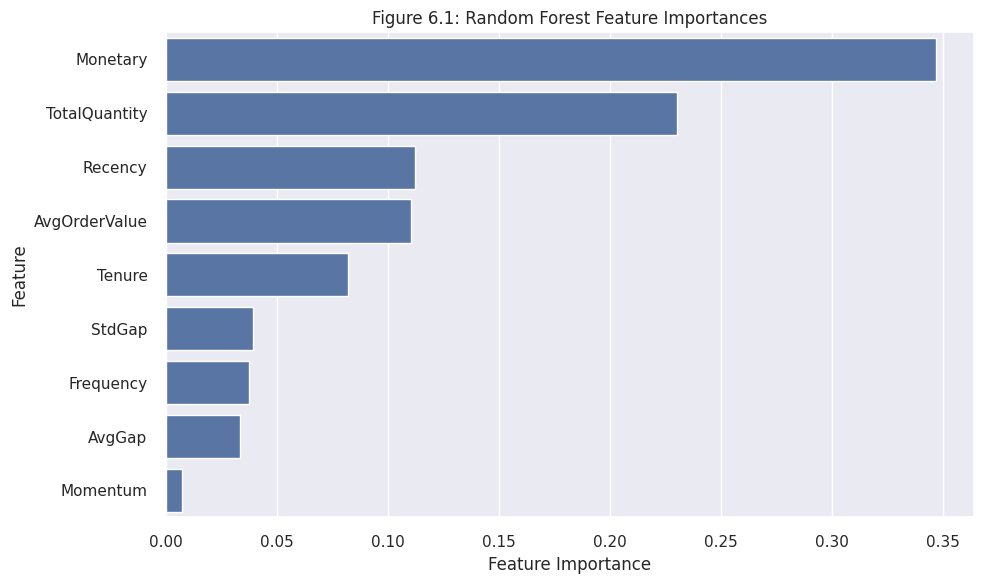

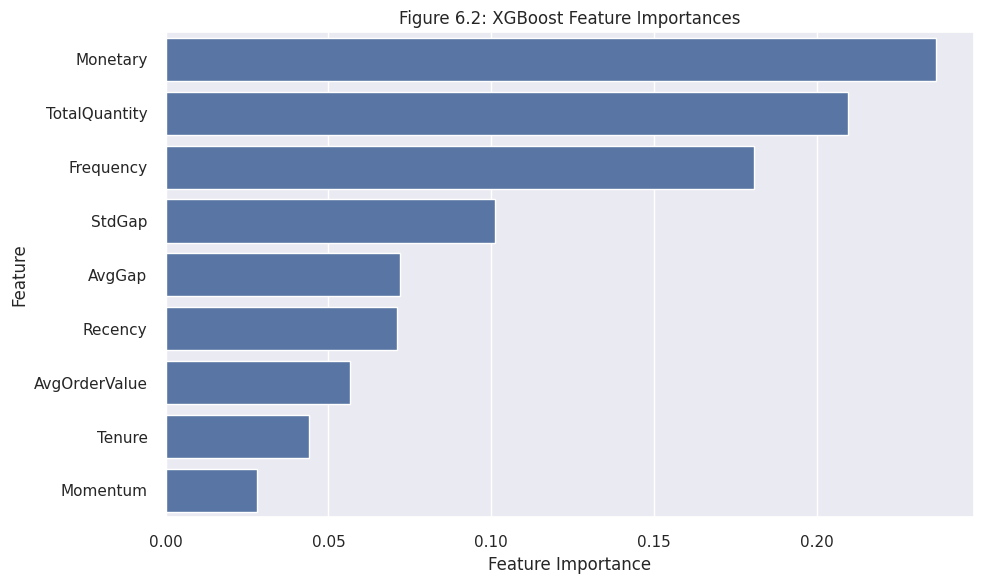

Random Forest and XGBoost Feature Importance plots generated and saved.


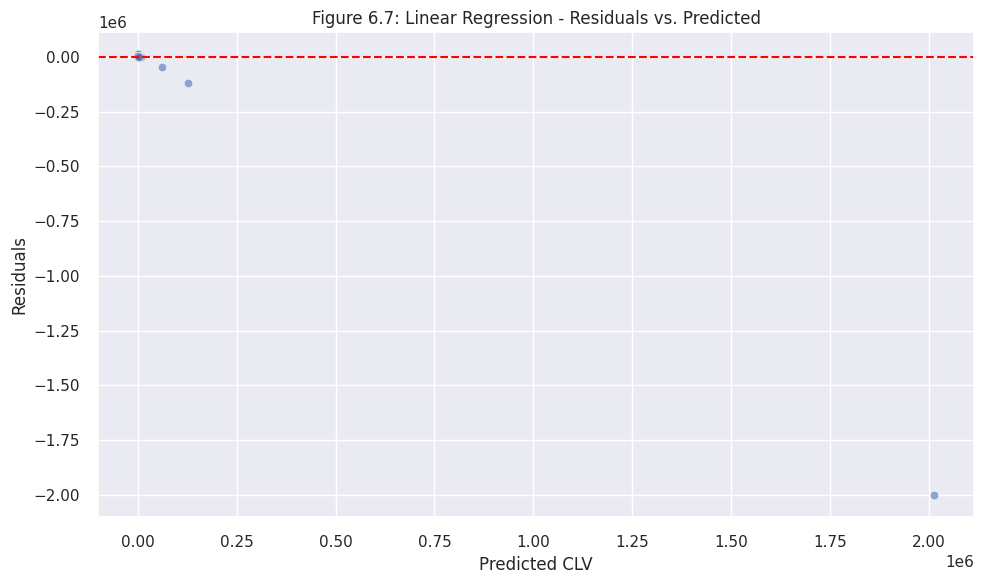

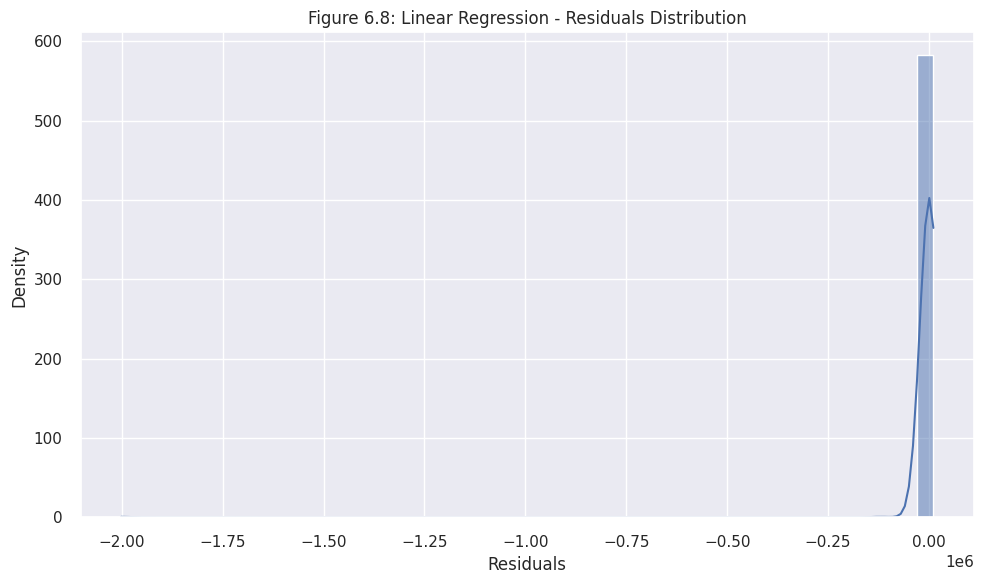

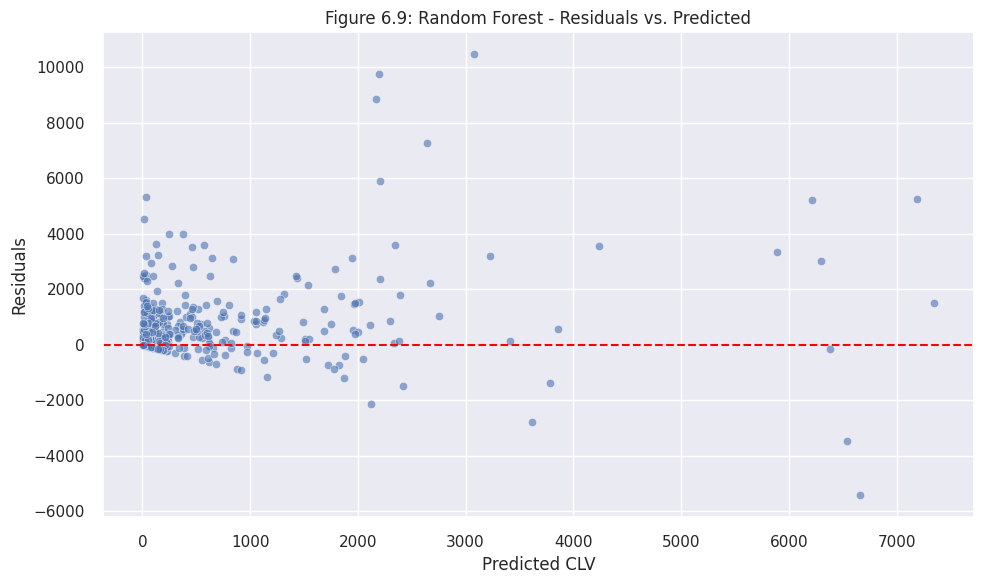

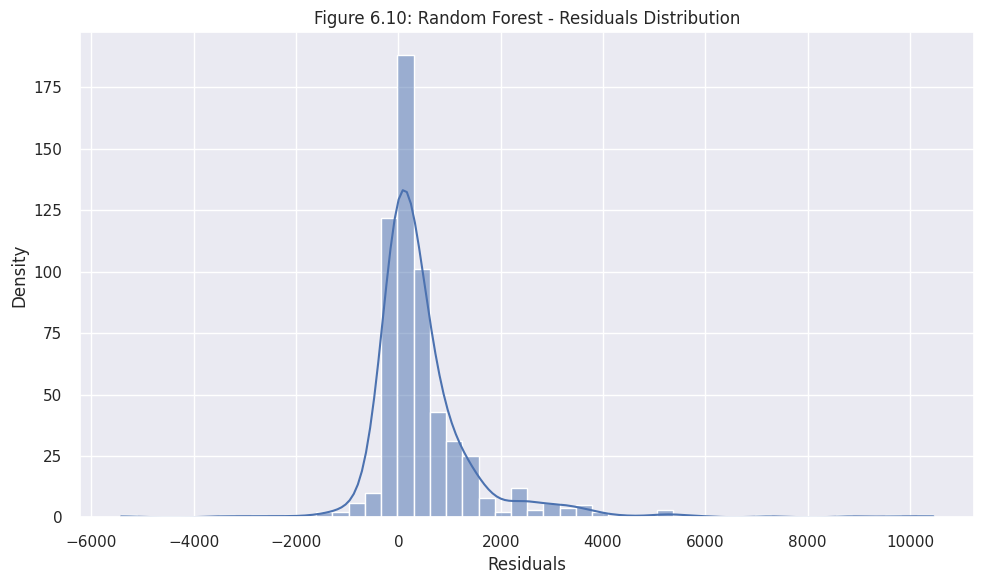

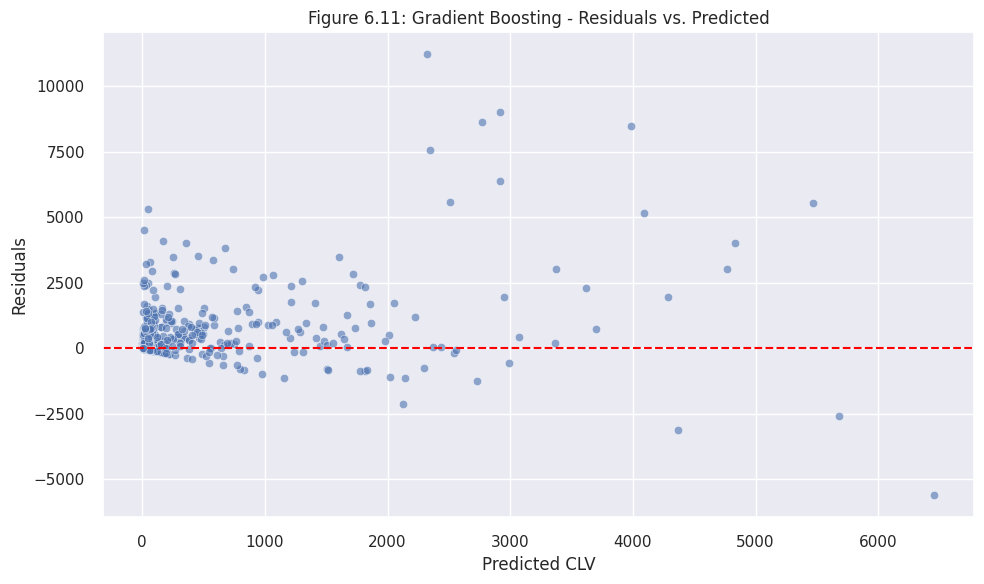

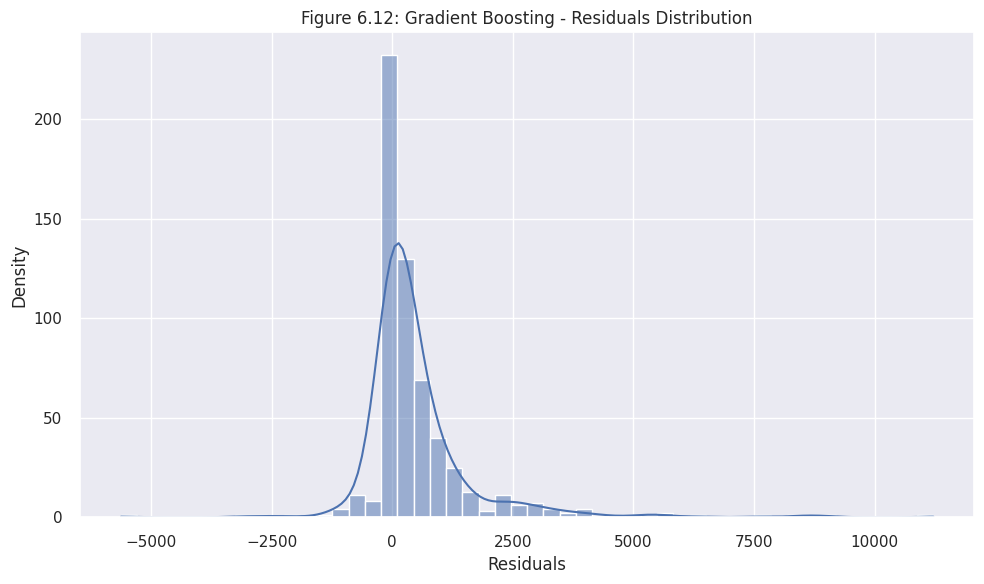

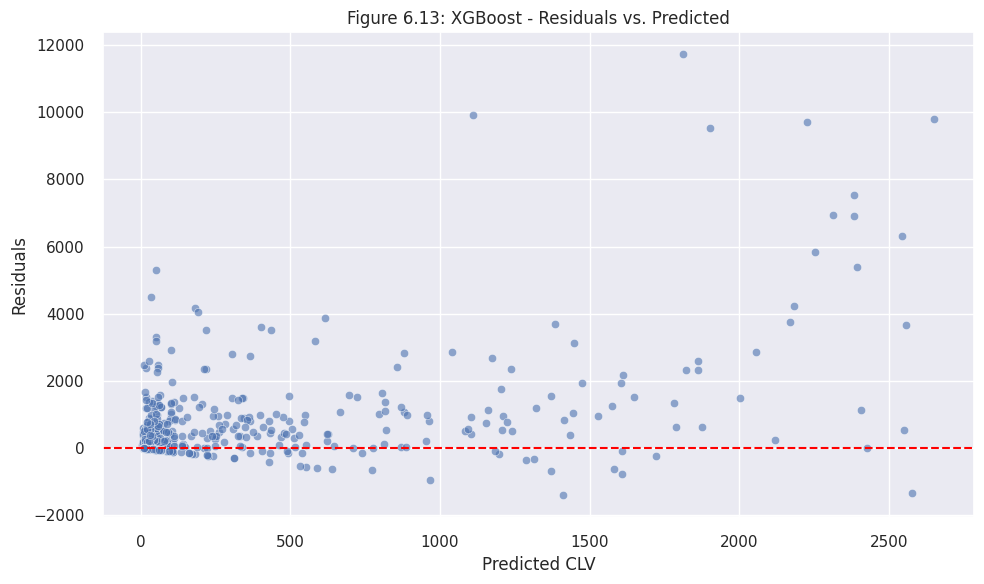

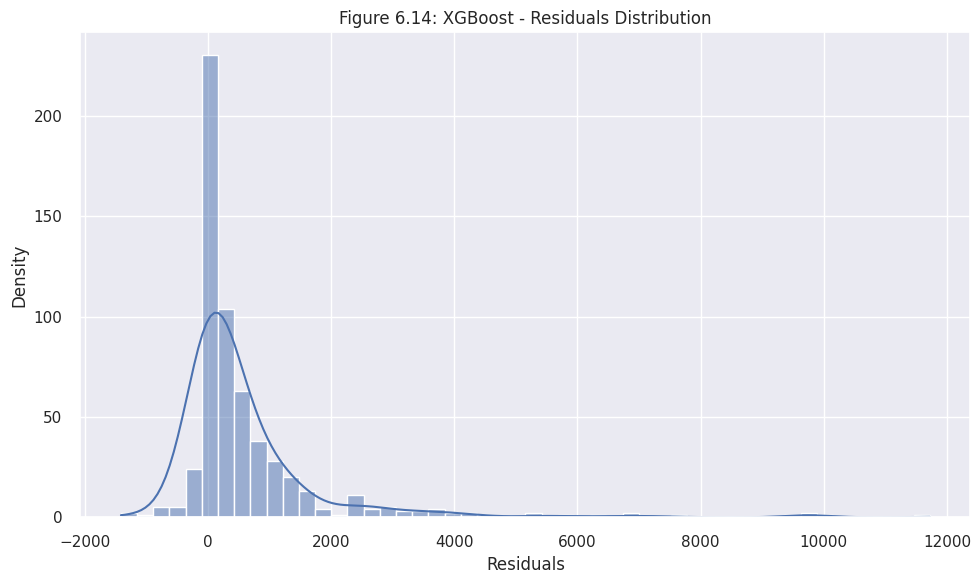

Residual plots generated and saved for all models.


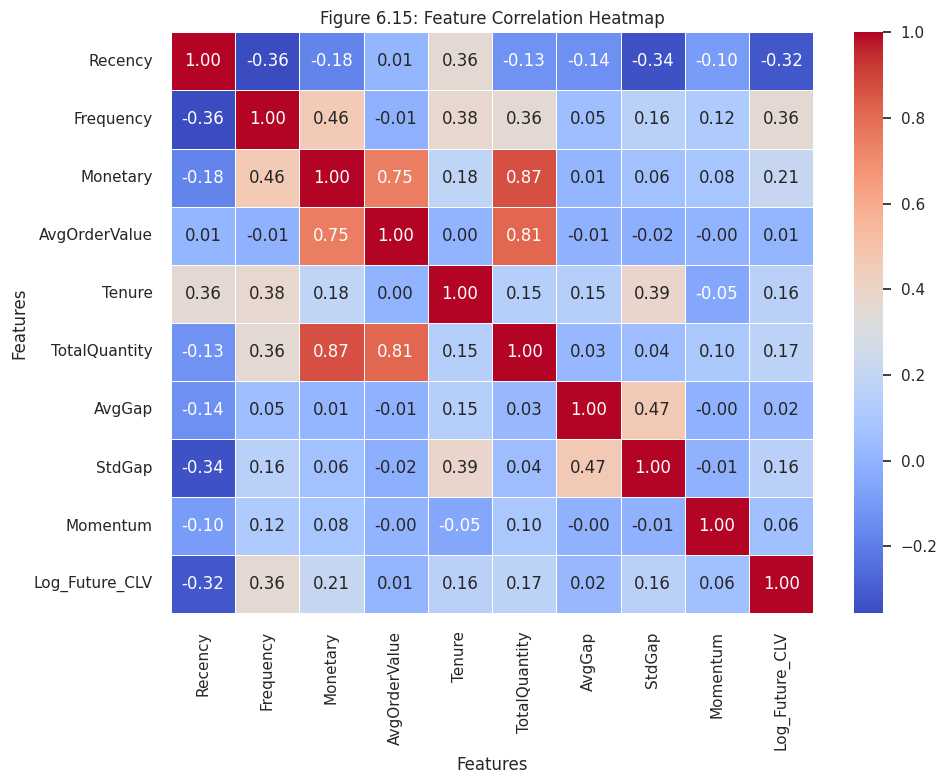

Feature Correlation Heatmap generated and saved.


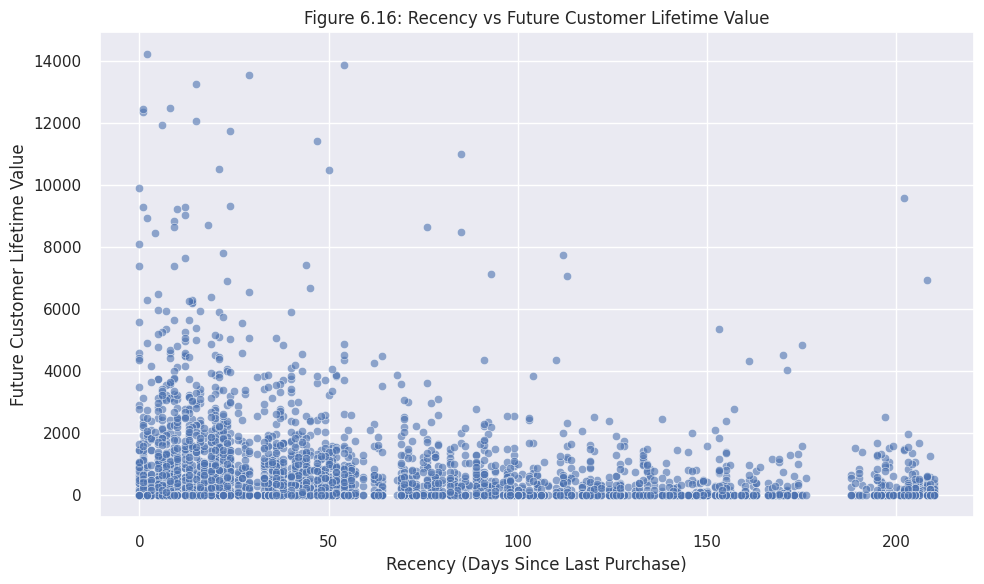

Recency vs Future CLV plot generated and saved.


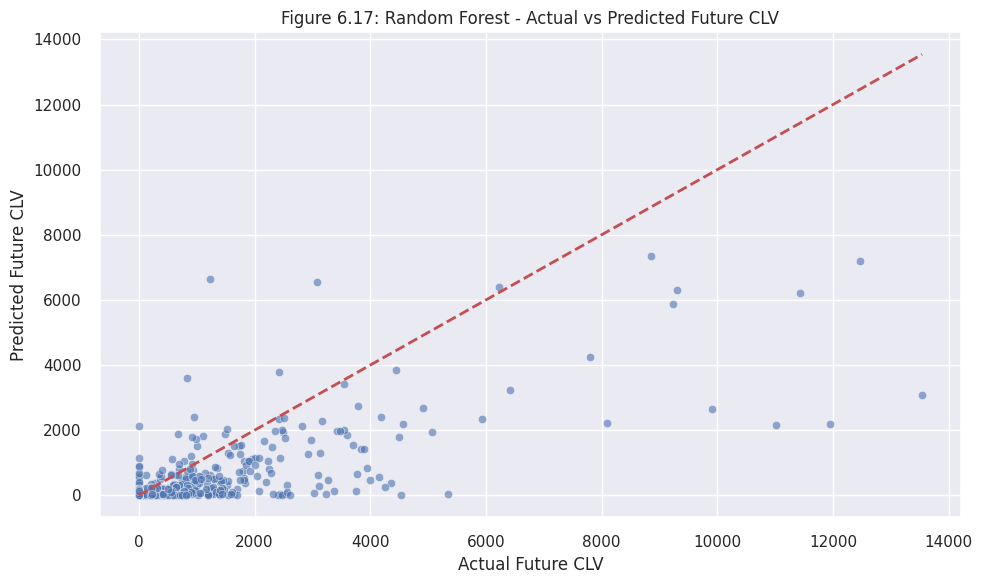

Actual vs Predicted Future CLV plot for Random Forest generated and saved.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_theme()

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")


df = pd.read_excel("/content/Online Retail.xlsx")

df.head()

# Remove missing customers
df = df.dropna(subset=["CustomerID"])

# Remove cancelled/negative transactions
df = df[df["Quantity"] > 0]

# Convert date column
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Create Revenue column
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df.shape

split_date = "2011-06-30"

observation = df[df["InvoiceDate"] <= split_date]
prediction = df[df["InvoiceDate"] > split_date]


reference_date = observation["InvoiceDate"].max()

recency = observation.groupby("CustomerID")["InvoiceDate"].max()
recency = (reference_date - recency).dt.days

frequency = observation.groupby("CustomerID")["InvoiceNo"].nunique()
monetary = observation.groupby("CustomerID")["Revenue"].sum()
avg_order = monetary / frequency

first_purchase = observation.groupby("CustomerID")["InvoiceDate"].min()
tenure = (reference_date - first_purchase).dt.days

total_quantity = observation.groupby("CustomerID")["Quantity"].sum()


obs_sorted = observation.sort_values(["CustomerID", "InvoiceDate"])

obs_sorted["PrevDate"] = obs_sorted.groupby("CustomerID")["InvoiceDate"].shift(1)
obs_sorted["Gap"] = (obs_sorted["InvoiceDate"] - obs_sorted["PrevDate"]).dt.days

avg_gap = obs_sorted.groupby("CustomerID")["Gap"].mean()
std_gap = obs_sorted.groupby("CustomerID")["Gap"].std()


mid_date = observation["InvoiceDate"].min() + \
           (reference_date - observation["InvoiceDate"].min()) / 2

first_half = observation[observation["InvoiceDate"] <= mid_date]
second_half = observation[observation["InvoiceDate"] > mid_date]

freq_first = first_half.groupby("CustomerID")["InvoiceNo"].nunique()
freq_second = second_half.groupby("CustomerID")["InvoiceNo"].nunique()

momentum = freq_second - freq_first


features = pd.concat([
    recency,
    frequency,
    monetary,
    avg_order,
    tenure,
    total_quantity,
    avg_gap,
    std_gap,
    momentum
], axis=1)

features.columns = [
    "Recency",
    "Frequency",
    "Monetary",
    "AvgOrderValue",
    "Tenure",
    "TotalQuantity",
    "AvgGap",
    "StdGap",
    "Momentum"
]

features = features.fillna(0)

# RFM Baseline metrics are now calculated when creating the comparison table

# Create Future CLV (Target Variable)
future_clv = prediction.groupby("CustomerID")["Revenue"].sum()
future_clv = future_clv.rename("Future_CLV")

data = features.merge(future_clv, on="CustomerID", how="left")
data["Future_CLV"] = data["Future_CLV"].fillna(0)

upper_limit = data["Future_CLV"].quantile(0.99)
data = data[data["Future_CLV"] <= upper_limit]

data["Log_Future_CLV"] = np.log1p(data["Future_CLV"])

X = data.drop(["Future_CLV", "Log_Future_CLV"], axis=1)
y = data["Log_Future_CLV"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)


# Random Forest with GridSearchCV
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
rf_grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
rf_grid_search.fit(X_train, y_train)
rf = rf_grid_search.best_estimator_

rf_pred = rf.predict(X_test)

# Evaluation
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

# Gradient Boosting (no GridSearchCV requested)
gbr = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.03,
    random_state=42
)

gbr.fit(X_train, y_train)

gbr_pred = gbr.predict(X_test)

gbr_mae = mean_absolute_error(
    y_test,
    gbr_pred
)

gbr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gbr_pred
    )
)

gbr_r2 = r2_score(
    y_test,
    gbr_pred
)


# XGBoost with GridSearchCV
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8]
}
xgb_grid_search = GridSearchCV(
    XGBRegressor(random_state=42, use_label_encoder=False, eval_metric='rmse'),
    xgb_param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
xgb_grid_search.fit(X_train, y_train)
xgb = xgb_grid_search.best_estimator_

xgb_pred = xgb.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)


# Create Final Comparison Table (RFM Baseline removed)
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],

    "MAE": [
        lr_mae,
        rf_mae,
        gbr_mae,
        xgb_mae
    ],

    "RMSE": [
        lr_rmse,
        rf_rmse,
        gbr_rmse,
        xgb_rmse
    ],

    "R2": [
        lr_r2,
        rf_r2,
        gbr_r2,
        xgb_r2
    ]
})

results = results.round(3)

results.sort_values("RMSE")

plt.scatter(data["Recency"], data["Future_CLV"], alpha=0.5)

plt.xlabel("Recency")
plt.ylabel("Future CLV")
plt.title("Recency vs Future Customer Value")

plt.show()

!ls

future_clv = prediction.groupby("CustomerID")["Revenue"].sum()
future_clv = future_clv.rename("Future_CLV")

data = features.merge(future_clv, on="CustomerID", how="left")
print(data.head())

future_clv = prediction.groupby("CustomerID")["Revenue"].sum()
future_clv = future_clv.rename("Future_CLV")

data = features.merge(future_clv, on="CustomerID", how="left")
data["Future_CLV"] = data["Future_CLV"].fillna(0)

upper_limit = data["Future_CLV"].quantile(0.99)
data = data[data["Future_CLV"] <= upper_limit]

data["Log_Future_CLV"] = np.log1p(data["Future_CLV"])

X = data.drop(["Future_CLV", "Log_Future_CLV"], axis=1)
y = data["Log_Future_CLV"]

print("Data after filling NaNs, capping outliers, and creating log-transformed target:")
print(data.head())
print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

tscv = TimeSeriesSplit(n_splits=5)
print(f"TimeSeriesSplit object created with {tscv.n_splits} splits.")

print("Demonstrating TimeSeriesSplit splits on training data (X_train, y_train):")
for fold, (train_index, val_index) in enumerate(tscv.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]
    print(f"Fold {fold+1}:")
    print(f"  Training samples: {len(X_train_fold)}")
    print(f"  Validation samples: {len(X_val_fold)}")

print("Starting GridSearchCV for RandomForestRegressor...")
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
rf_grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=tscv, # Use TimeSeriesSplit here
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
rf_grid_search.fit(X_train, y_train)

best_rf_params = rf_grid_search.best_params_
best_rf_score = rf_grid_search.best_score_

print(f"Best RandomForestRegressor Parameters: {best_rf_params}")
print(f"Best RandomForestRegressor Score (neg_mean_squared_error): {best_rf_score}")

print("Starting GridSearchCV for XGBRegressor...")
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8]
}
xgb_grid_search = GridSearchCV(
    XGBRegressor(random_state=42, use_label_encoder=False, eval_metric='rmse', n_jobs=-1),
    xgb_param_grid,
    cv=tscv, # Use TimeSeriesSplit here
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
xgb_grid_search.fit(X_train, y_train)

best_xgb_params = xgb_grid_search.best_params_
best_xgb_score = xgb_grid_search.best_score_

print(f"Best XGBRegressor Parameters: {best_xgb_params}")
print(f"Best XGBRegressor Score (neg_mean_squared_error): {best_xgb_score}")

lr_mae_scores, lr_rmse_scores, lr_r2_scores = [], [], []
rf_mae_scores, rf_rmse_scores, rf_r2_scores = [], [], []
gbr_mae_scores, gbr_rmse_scores, gbr_r2_scores = [], [], []
xgb_mae_scores, xgb_rmse_scores, xgb_r2_scores = [], [], []

print("Initialized lists to store evaluation metrics for all models.")

for fold, (train_index, val_index) in enumerate(tscv.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Linear Regression
    lr_model = LinearRegression()
    lr_model.fit(X_train_fold, y_train_fold)
    lr_pred_fold = lr_model.predict(X_val_fold)
    lr_mae_scores.append(mean_absolute_error(np.expm1(y_val_fold), np.expm1(lr_pred_fold)))
    lr_rmse_scores.append(np.sqrt(mean_squared_error(np.expm1(y_val_fold), np.expm1(lr_pred_fold))))
    lr_r2_scores.append(r2_score(np.expm1(y_val_fold), np.expm1(lr_pred_fold)))

    # Random Forest
    rf_model = RandomForestRegressor(random_state=42, n_jobs=-1, **best_rf_params)
    rf_model.fit(X_train_fold, y_train_fold)
    rf_pred_fold = rf_model.predict(X_val_fold)
    rf_mae_scores.append(mean_absolute_error(np.expm1(y_val_fold), np.expm1(rf_pred_fold)))
    rf_rmse_scores.append(np.sqrt(mean_squared_error(np.expm1(y_val_fold), np.expm1(rf_pred_fold))))
    rf_r2_scores.append(r2_score(np.expm1(y_val_fold), np.expm1(rf_pred_fold)))

    # Gradient Boosting
    gbr_model = GradientBoostingRegressor(n_estimators=500, learning_rate=0.03, random_state=42)
    gbr_model.fit(X_train_fold, y_train_fold)
    gbr_pred_fold = gbr_model.predict(X_val_fold)
    gbr_mae_scores.append(mean_absolute_error(np.expm1(y_val_fold), np.expm1(gbr_pred_fold)))
    gbr_rmse_scores.append(np.sqrt(mean_squared_error(np.expm1(y_val_fold), np.expm1(gbr_pred_fold))))
    gbr_r2_scores.append(r2_score(np.expm1(y_val_fold), np.expm1(gbr_pred_fold)))

    # XGBoost
    xgb_model = XGBRegressor(random_state=42, use_label_encoder=False, eval_metric='rmse', n_jobs=-1, **best_xgb_params)
    xgb_model.fit(X_train_fold, y_train_fold)
    xgb_pred_fold = xgb_model.predict(X_val_fold)
    xgb_mae_scores.append(mean_absolute_error(np.expm1(y_val_fold), np.expm1(xgb_pred_fold)))
    xgb_rmse_scores.append(np.sqrt(mean_squared_error(np.expm1(y_val_fold), np.expm1(xgb_pred_fold))))
    xgb_r2_scores.append(r2_score(np.expm1(y_val_fold), np.expm1(xgb_pred_fold)))

    print(f"Fold {fold + 1} completed.")

print("Cross-validation completed for all models.")

print("\n--- Cross-Validation Results ---")

# Linear Regression
print("\nLinear Regression:")
print(f"  Mean MAE: {np.mean(lr_mae_scores):.3f} (Std: {np.std(lr_mae_scores):.3f})")
print(f"  Mean RMSE: {np.mean(lr_rmse_scores):.3f} (Std: {np.std(lr_rmse_scores):.3f})")
print(f"  Mean R2: {np.mean(lr_r2_scores):.3f} (Std: {np.std(lr_r2_scores):.3f})")

# Random Forest
print("\nRandom Forest:")
print(f"  Mean MAE: {np.mean(rf_mae_scores):.3f} (Std: {np.std(rf_mae_scores):.3f})")
print(f"  Mean RMSE: {np.mean(rf_rmse_scores):.3f} (Std: {np.std(rf_rmse_scores):.3f})")
print(f"  Mean R2: {np.mean(rf_r2_scores):.3f} (Std: {np.std(rf_r2_scores):.3f})")

# Gradient Boosting
print("\nGradient Boosting:")
print(f"  Mean MAE: {np.mean(gbr_mae_scores):.3f} (Std: {np.std(gbr_mae_scores):.3f})")
print(f"  Mean RMSE: {np.mean(gbr_rmse_scores):.3f} (Std: {np.std(gbr_rmse_scores):.3f})")
print(f"  Mean R2: {np.mean(gbr_r2_scores):.3f} (Std: {np.std(gbr_r2_scores):.3f})")

# XGBoost
print("\nXGBoost:")
print(f"  Mean MAE: {np.mean(xgb_mae_scores):.3f} (Std: {np.std(xgb_mae_scores):.3f})")
print(f"  Mean RMSE: {np.mean(xgb_rmse_scores):.3f} (Std: {np.std(xgb_rmse_scores):.3f})")
print(f"  Mean R2: {np.mean(xgb_r2_scores):.3f} (Std: {np.std(xgb_r2_scores):.3f})")

print("\n--- Statistical Validation and Confidence Intervals ---")

def print_metrics_and_ci(model_name, mae_scores, rmse_scores, r2_scores):
    mean_mae, std_mae = np.mean(mae_scores), np.std(mae_scores)
    mean_rmse, std_rmse = np.mean(rmse_scores), np.std(rmse_scores)
    mean_r2, std_r2 = np.mean(r2_scores), np.std(r2_scores)

    # Calculate 95% Confidence Interval for RMSE
    n_folds = len(rmse_scores)
    if n_folds > 1:
        rmse_ci_lower = mean_rmse - 1.96 * (std_rmse / np.sqrt(n_folds))
        rmse_ci_upper = mean_rmse + 1.96 * (std_rmse / np.sqrt(n_folds))
        ci_str = f" (95% CI: [{rmse_ci_lower:.3f}, {rmse_ci_upper:.3f}])"
    else:
        ci_str = " (CI not applicable for 1 fold)"

    print(f"\n{model_name}:")
    print(f"  Mean MAE: {mean_mae:.3f} (Std: {std_mae:.3f})")
    print(f"  Mean RMSE: {mean_rmse:.3f} (Std: {std_rmse:.3f}){ci_str}")
    print(f"  Mean R2: {mean_r2:.3f} (Std: {std_r2:.3f})")

# Linear Regression
print_metrics_and_ci("Linear Regression", lr_mae_scores, lr_rmse_scores, lr_r2_scores)

# Random Forest
print_metrics_and_ci("Random Forest", rf_mae_scores, rf_rmse_scores, rf_r2_scores)

# Gradient Boosting
print_metrics_and_ci("Gradient Boosting", gbr_mae_scores, gbr_rmse_scores, gbr_r2_scores)

# XGBoost
print_metrics_and_ci("XGBoost", xgb_mae_scores, xgb_rmse_scores, xgb_r2_scores)

rf_feature_importances = rf_model.feature_importances_
xgb_feature_importances = xgb_model.feature_importances_

print("Random Forest Feature Importances extracted.")
print("XGBoost Feature Importances extracted.")

rf_feature_importances = rf_model.feature_importances_
xgb_feature_importances = xgb_model.feature_importances_

# Create DataFrame for Random Forest Feature Importances
rf_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_feature_importances
}).sort_values(by='Importance', ascending=False)

# Create DataFrame for XGBoost Feature Importances
xgb_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_feature_importances
}).sort_values(by='Importance', ascending=False)

print("Random Forest Feature Importances:")
print(rf_importance_df.to_markdown(index=False))

print("\nXGBoost Feature Importances:")
print(xgb_importance_df.to_markdown(index=False))

# Visualize Random Forest Feature Importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_importance_df)
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Visualize XGBoost Feature Importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=xgb_importance_df)
plt.title('XGBoost Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Random Forest and XGBoost Feature Importances extracted and visualized.")

print("Training models and making predictions for residual analysis...")

y_test_original = np.expm1(y_test)

# Linear Regression
lr_model_final = LinearRegression()
lr_model_final.fit(X_train, y_train)
lr_pred_final = np.expm1(lr_model_final.predict(X_test))
lr_residuals = y_test_original - lr_pred_final

# Random Forest
rf_model_final = RandomForestRegressor(random_state=42, n_jobs=-1, **best_rf_params)
rf_model_final.fit(X_train, y_train)
rf_pred_final = np.expm1(rf_model_final.predict(X_test))
rf_residuals = y_test_original - rf_pred_final

# Gradient Boosting
gbr_model_final = GradientBoostingRegressor(n_estimators=500, learning_rate=0.03, random_state=42)
gbr_model_final.fit(X_train, y_train)
gbr_pred_final = np.expm1(gbr_model_final.predict(X_test))
gbr_residuals = y_test_original - gbr_pred_final

# XGBoost
xgb_model_final = XGBRegressor(random_state=42, use_label_encoder=False, eval_metric='rmse', n_jobs=-1, **best_xgb_params)
xgb_model_final.fit(X_train, y_train)
xgb_pred_final = np.expm1(xgb_model_final.predict(X_test))
xgb_residuals = y_test_original - xgb_pred_final

print("Models trained, predictions made, and residuals calculated.")
print("\nFirst 5 Linear Regression Residuals:", lr_residuals.head().values)
print("First 5 Random Forest Residuals:", rf_residuals.head().values)
print("First 5 Gradient Boosting Residuals:", gbr_residuals.head().values)
print("First 5 XGBoost Residuals:", xgb_residuals.head().values)

models_for_plot = {
    "Linear Regression": (lr_pred_final, lr_residuals),
    "Random Forest": (rf_pred_final, rf_residuals),
    "Gradient Boosting": (gbr_pred_final, gbr_residuals),
    "XGBoost": (xgb_pred_final, xgb_residuals)
}

plt.figure(figsize=(16, 12))
for i, (model_name, (predictions, residuals)) in enumerate(models_for_plot.items()):
    # Residuals vs. Predicted Values Plot
    plt.subplot(2, 4, i + 1)
    sns.scatterplot(x=predictions, y=residuals, alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'{model_name}: Residuals vs. Predicted')
    plt.xlabel('Predicted CLV')
    plt.ylabel('Residuals')

    # Residuals Distribution Plot
    plt.subplot(2, 4, i + 5)
    sns.histplot(residuals, kde=True, bins=50)
    plt.title(f'{model_name}: Residuals Distribution')
    plt.xlabel('Residuals')
    plt.ylabel('Density')

plt.tight_layout()
plt.show()

print("Residual plots generated and displayed for all models.")

descriptive_stats_df = pd.concat([X, data['Future_CLV']], axis=1)
descriptive_statistics = descriptive_stats_df.describe().T

print("Table 1: Descriptive Statistics for Engineered Features and Future_CLV")
print(descriptive_statistics.to_markdown(numalign="left", stralign="left"))

corr_df = pd.concat([X, y], axis=1)
correlation_matrix = corr_df.corr()

print("Table 2: Feature Correlation Matrix")
print(correlation_matrix.to_markdown(numalign="left", stralign="left"))

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Feature Correlation Heatmap')
plt.show()

print("Feature correlation matrix and heatmap generated and displayed.")

model_performance_data = {
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "Mean MAE": [
        np.mean(lr_mae_scores),
        np.mean(rf_mae_scores),
        np.mean(gbr_mae_scores),
        np.mean(xgb_mae_scores)
    ],
    "Mean RMSE": [
        np.mean(lr_rmse_scores),
        np.mean(rf_rmse_scores),
        np.mean(gbr_rmse_scores),
        np.mean(xgb_rmse_scores)
    ],
    "Mean R²": [
        np.mean(lr_r2_scores),
        np.mean(rf_r2_scores),
        np.mean(gbr_r2_scores),
        np.mean(xgb_r2_scores)
    ]
}

model_performance_df = pd.DataFrame(model_performance_data)

# Sort by Mean RMSE
model_performance_df_sorted = model_performance_df.sort_values(by="Mean RMSE").round(3)

print("Table 3: Model Performance (on back-transformed CLV values)")
print(model_performance_df_sorted.to_markdown(index=False, numalign="left", stralign="left"))

def calculate_rmse_stats(rmse_scores):
    mean_rmse = np.mean(rmse_scores)
    std_rmse = np.std(rmse_scores)
    n_folds = len(rmse_scores)
    if n_folds > 1:
        rmse_ci_lower = mean_rmse - 1.96 * (std_rmse / np.sqrt(n_folds))
        rmse_ci_upper = mean_rmse + 1.96 * (std_rmse / np.sqrt(n_folds))
    else:
        rmse_ci_lower, rmse_ci_upper = np.nan, np.nan # Not applicable for 1 fold
    return mean_rmse, std_rmse, rmse_ci_lower, rmse_ci_upper

# Calculate stats for each model
lr_mean_rmse, lr_std_rmse, lr_ci_lower, lr_ci_upper = calculate_rmse_stats(lr_rmse_scores)
rf_mean_rmse, rf_std_rmse, rf_ci_lower, rf_ci_upper = calculate_rmse_stats(rf_rmse_scores)
gbr_mean_rmse, gbr_std_rmse, gbr_ci_lower, gbr_ci_upper = calculate_rmse_stats(gbr_rmse_scores)
xgb_mean_rmse, xgb_std_rmse, xgb_ci_lower, xgb_ci_upper = calculate_rmse_stats(xgb_rmse_scores)

# Create DataFrame for Table 4
cv_results_data = {
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "Mean RMSE": [
        lr_mean_rmse,
        rf_mean_rmse,
        gbr_mean_rmse,
        xgb_mean_rmse
    ],
    "Std Dev RMSE": [
        lr_std_rmse,
        rf_std_rmse,
        gbr_std_rmse,
        xgb_std_rmse
    ],
    "95% CI Lower": [
        lr_ci_lower,
        rf_ci_lower,
        gbr_ci_lower,
        xgb_ci_lower
    ],
    "95% CI Upper": [
        lr_ci_upper,
        rf_ci_upper,
        gbr_ci_upper,
        xgb_ci_upper
    ]
}

cv_results_df = pd.DataFrame(cv_results_data)

# Sort by Mean RMSE and round to 3 decimal places for display
cv_results_df_sorted = cv_results_df.sort_values(by="Mean RMSE").round(3)

print("Table 4: Cross-Validation Results (RMSE)")
print(cv_results_df_sorted.to_markdown(index=False, numalign="left", stralign="left"))

hyperparameters_data = []

for param, value in best_rf_params.items():
    hyperparameters_data.append({
        'Model': 'Random Forest',
        'Hyperparameter': param,
        'Value': value
    })

for param, value in best_xgb_params.items():
    hyperparameters_data.append({
        'Model': 'XGBoost',
        'Hyperparameter': param,
        'Value': value
    })

best_hyperparameters_df = pd.DataFrame(hyperparameters_data)

print("Table 5: Best Hyperparameters")
print(best_hyperparameters_df.to_markdown(index=False, numalign="left", stralign="left"))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_importance_df)
plt.title('Figure 6.1: Random Forest Feature Importances')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('rf_feature_importance.png')
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=xgb_importance_df)
plt.title('Figure 6.2: XGBoost Feature Importances')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png')
plt.show()

print("Random Forest and XGBoost Feature Importance plots generated and saved.")



models_for_plot = {
    "Linear Regression": (lr_pred_final, lr_residuals),
    "Random Forest": (rf_pred_final, rf_residuals),
    "Gradient Boosting": (gbr_pred_final, gbr_residuals),
    "XGBoost": (xgb_pred_final, xgb_residuals)
}

fig_num_start = 6

for i, (model_name, (predictions, residuals)) in enumerate(models_for_plot.items()):
    # Residuals vs. Predicted Values Plot
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=predictions, y=residuals, alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Figure 6.{fig_num_start + (i*2) + 1}: {model_name} - Residuals vs. Predicted')
    plt.xlabel('Predicted CLV')
    plt.ylabel('Residuals')
    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ", "_").lower()}_residuals_vs_predicted.png')
    plt.show()

    # Residuals Distribution Plot
    plt.figure(figsize=(10, 6))
    sns.histplot(residuals, kde=True, bins=50)
    plt.title(f'Figure 6.{fig_num_start + (i*2) + 2}: {model_name} - Residuals Distribution')
    plt.xlabel('Residuals')
    plt.ylabel('Density')
    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ", "_").lower()}_residuals_distribution.png')
    plt.show()

print("Residual plots generated and saved for all models.")

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Figure 6.15: Feature Correlation Heatmap')
plt.xlabel('Features')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('feature_correlation_heatmap.png')
plt.show()

print("Feature Correlation Heatmap generated and saved.")

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Recency', y='Future_CLV', data=data, alpha=0.6)
plt.title('Figure 6.16: Recency vs Future Customer Lifetime Value') # Continuing figure numbering
plt.xlabel('Recency (Days Since Last Purchase)')
plt.ylabel('Future Customer Lifetime Value')
plt.tight_layout()
plt.savefig('recency_vs_future_clv.png')
plt.show()

print("Recency vs Future CLV plot generated and saved.")

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_original, y=rf_pred_final, alpha=0.6)
plt.title('Figure 6.17: Random Forest - Actual vs Predicted Future CLV')
plt.xlabel('Actual Future CLV')
plt.ylabel('Predicted Future CLV')
plt.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], 'r--', lw=2)
plt.tight_layout()
plt.savefig('rf_actual_vs_predicted_clv.png')
plt.show()

print("Actual vs Predicted Future CLV plot for Random Forest generated and saved.")